# **Information Gain Assignment**
## **Group 2:** Kareem Piper, Jillian Mouser, Jeani Pendergraft, Cheyanne Allred-Lopez

The textbook is referenced throughout the assignment. Please see the reference below:

#### **Reference:**

Han, J., Pei, J., & Tong, H. (2022). Data mining: concepts and techniques (4th ed.). 	Morgan Kaufmann.

### **Function Implementation**

The following section implements Equations 6.2, 6.3, and 6.4, which are needed to calculate the information gain on each attribute.

In [ ]:
def return_target_probabilities(dataframe, class_label):
  probabilities = {}
  target_class_values = pd.DataFrame(dataframe[class_label].value_counts())
  total = target_class_values['count'].sum()
  for index, row in target_class_values.iterrows():
    probabilities[index] = row['count'] / total
  return probabilities

The following function calculated the entropy of the dataset, using Equation 6.2 in the textbook (pg. 249):

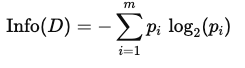

It can be thought of as "the average amount of information needed to identify the class label of a tuple in D", where D is the training dataset.


In [ ]:
# Calculate and return the expected information needed to classify a tuple in the dataset.

def calculate_entropy(dataframe, column_label = None):
  information = 0
  if column_label:
    target_class_values = pd.DataFrame(dataframe[column_label].value_counts())
  else:
    target_class_values = dataframe
  total = target_class_values['count'].sum()
  for index, row in target_class_values.iterrows():
    probability = row['count'] / total
    information -= probability * math.log2(probability)
  return information

The following function calculates the conditional entropy for each attribute in a given DataFrame, using Equation 6.3 in the textbook (pg. 250).


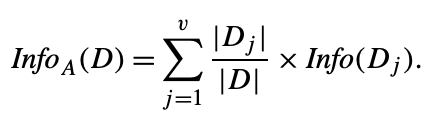

Let A be the attribute on which we are partitioning the dataset, *D*.

The conditional entropy is therefore the "expected information required to classify a tuple from *D* based on the partitioning by A.

In [ ]:
def calculate_conditional_entropy(dataframe, target_class):
  conditional_entropy = {}
  for column in dataframe.columns:
    if column == target_class:
      continue
    else:
      attribute_conditional_entropy = 0
      weights = return_target_probabilities(dataframe, column)
      grouped_df = pd.DataFrame(dataframe.groupby([column, target_class]).size(), columns = ['count'])
      for key in weights.keys():
        df = pd.DataFrame(grouped_df.loc[key])
        information = calculate_entropy(df)
        attribute_conditional_entropy += weights[key] * information
      conditional_entropy[column] = attribute_conditional_entropy
  return conditional_entropy

The following function calculates the information gain for each attribute in the given DataFrame, using Equation 6.4 in the textbook (pg. 250).

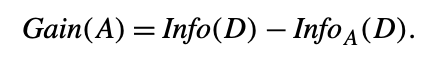

The information gain "tells us how much would be gained by branching on A".

The DataFrame returned by the function is ordered in descending order by the calculated gain. The first attribute should be used as the root node, N, in the resulting decision tree, as it is the attribute that gives us the largest amount of information gain (AKA - minimizes the amount of information which still needs to be found).


In [ ]:
def calculate_information_gain(entropy, conditional_entropy):
  gain_df = pd.DataFrame(columns = ['Gain'])
  for key in conditional_entropy.keys():
    gain_df.loc[key] = entropy - conditional_entropy[key]
  gain_df = gain_df.sort_values(by = 'Gain', ascending = False)
  return gain_df

In [ ]:
def calculate_gain_dataset(dataframe, target_attribute):
  entropy = calculate_entropy(dataframe, target_attribute)
  conditional_entropy = calculate_conditional_entropy(dataframe, target_attribute)
  return calculate_information_gain(entropy, conditional_entropy)

### **Data Preprocessing:**

In [ ]:
import pandas as pd
import math
import pydantic

In [ ]:
# from google.colab import files
# uploaded = files.upload()

In [ ]:
# Uploading p2_dataset_binned2.csv
# Update file path if using different dataset.

df = pd.read_csv('/content/p2_dataset_binned2.csv')
df.head()

,magnitude,mmi,sig,nst,dmin,depth,latitude,longitude,Year,Month,tsunami,magnitude_bin,mmi_bin,sig_bin,nst_bin,dmin_bin,depth_bin,year_bin,month_bin,location_bin
0,7.0,7,768,117,0.509,14.000,-9.7963,159.596,2022,11,1,6.5-7.5,Strong to very strong,Low,Low,Excellent,Shallow-focus,2013-2022,Q4,SE
1,6.9,4,735,99,2.229,25.000,-4.9559,100.738,2022,11,0,6.5-7.5,Light to moderate intensity,Low,Low,Good,Shallow-focus,2013-2022,Q4,SE
2,7.0,3,755,147,3.125,579.000,-20.0508,-178.346,2022,11,1,6.5-7.5,Weak or not felt,Low,Low,Good,Deep-focus,2013-2022,Q4,SW
3,7.3,5,833,149,1.865,37.000,-19.2918,-172.129,2022,11,1,6.5-7.5,Light to moderate intensity,Low,Low,Good,Shallow-focus,2013-2022,Q4,SW
4,6.6,2,670,131,4.998,624.464,-25.5948,178.278,2022,11,1,6.5-7.5,Weak or not felt,Low,Low,Good,Deep-focus,2013-2022,Q4,SE


In [ ]:
# Using only the binned columns, computed in Project #2, to increase simplicity for information gain calculations.
# Referencing pg. 250 in the textbook: "In this example, each attribute is discrete-valued. Continuous valued attributes have been generalized"
trimmed_df = df.drop(columns=['magnitude', 'mmi', 'sig', 'nst', 'dmin', 'depth', 'latitude', 'longitude', 'Year', 'Month'])

trimmed_df.head()

,tsunami,magnitude_bin,mmi_bin,sig_bin,nst_bin,dmin_bin,depth_bin,year_bin,month_bin,location_bin
0,1,6.5-7.5,Strong to very strong,Low,Low,Excellent,Shallow-focus,2013-2022,Q4,SE
1,0,6.5-7.5,Light to moderate intensity,Low,Low,Good,Shallow-focus,2013-2022,Q4,SE
2,1,6.5-7.5,Weak or not felt,Low,Low,Good,Deep-focus,2013-2022,Q4,SW
3,1,6.5-7.5,Light to moderate intensity,Low,Low,Good,Shallow-focus,2013-2022,Q4,SW
4,1,6.5-7.5,Weak or not felt,Low,Low,Good,Deep-focus,2013-2022,Q4,SE


### **Information Gain Calculation:**

The following code calculates the information gain for each attribute in the trimmed 'Tsunami' dataset.

In [ ]:
tsunami_gain = calculate_gain_dataset(trimmed_df, 'tsunami')
display(tsunami_gain)

,Gain
year_bin,0.512123
nst_bin,0.343303
dmin_bin,0.202107
location_bin,0.041030
mmi_bin,0.012015
sig_bin,0.005028
magnitude_bin,0.004563
depth_bin,0.002654
month_bin,0.001509


### **Check:**

The following code recreates the datasets provided by the textbook on Page 250 and tests the calculations.

In [ ]:
# Data as a list of dictionaries
data = [
    {'age': 'youth',        'income': 'high',   'student': 'no',  'credit_rating': 'fair',      'buys_computer': 'no'},
    {'age': 'youth',        'income': 'high',   'student': 'no',  'credit_rating': 'excellent','buys_computer': 'no'},
    {'age': 'middle_aged',  'income': 'high',   'student': 'no',  'credit_rating': 'fair',      'buys_computer': 'yes'},
    {'age': 'senior',       'income': 'medium', 'student': 'no',  'credit_rating': 'fair',      'buys_computer': 'yes'},
    {'age': 'senior',       'income': 'low',    'student': 'yes', 'credit_rating': 'fair',      'buys_computer': 'yes'},
    {'age': 'senior',       'income': 'low',    'student': 'yes', 'credit_rating': 'excellent','buys_computer': 'no'},
    {'age': 'middle_aged',  'income': 'low',    'student': 'yes', 'credit_rating': 'excellent','buys_computer': 'yes'},
    {'age': 'youth',        'income': 'medium', 'student': 'no',  'credit_rating': 'fair',      'buys_computer': 'no'},
    {'age': 'youth',        'income': 'low',    'student': 'yes', 'credit_rating': 'fair',      'buys_computer': 'yes'},
    {'age': 'senior',       'income': 'medium', 'student': 'yes', 'credit_rating': 'fair',      'buys_computer': 'yes'},
    {'age': 'youth',        'income': 'medium', 'student': 'yes', 'credit_rating': 'excellent','buys_computer': 'yes'},
    {'age': 'middle_aged',  'income': 'medium', 'student': 'no',  'credit_rating': 'excellent','buys_computer': 'yes'},
    {'age': 'middle_aged',  'income': 'high',   'student': 'yes', 'credit_rating': 'fair',      'buys_computer': 'yes'},
    {'age': 'senior',       'income': 'medium', 'student': 'no',  'credit_rating': 'excellent','buys_computer': 'no'}
]

# Create the DataFrame
test_df = pd.DataFrame(data, columns=['age', 'income', 'student', 'credit_rating', 'buys_computer'])

display(test_df)

,age,income,student,credit_rating,buys_computer
0,youth,high,no,fair,no
1,youth,high,no,excellent,no
2,middle_aged,high,no,fair,yes
3,senior,medium,no,fair,yes
4,senior,low,yes,fair,yes
5,senior,low,yes,excellent,no
6,middle_aged,low,yes,excellent,yes
7,youth,medium,no,fair,no
8,youth,low,yes,fair,yes
9,senior,medium,yes,fair,yes


In [ ]:
test_gain = calculate_gain_dataset(test_df, 'buys_computer')
display(test_gain)

,Gain
age,0.246750
student,0.151836
credit_rating,0.048127
income,0.029223
